In [0]:
import pandas as pd

df=pd.read_csv("/Volumes/vita/dataengineering/data/ml_project/Food_Delivery_Times.csv")

In [0]:
print(df.head())
print(df.shape
)


   Order_ID  Distance_km  ... Courier_Experience_yrs Delivery_Time_min
0       522         7.93  ...                    1.0                43
1       738        16.42  ...                    2.0                84
2       741         9.52  ...                    1.0                59
3       661         7.44  ...                    1.0                37
4       412        19.03  ...                    5.0                68

[5 rows x 9 columns]
(1000, 9)


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [0]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [0]:
df.drop("Order_ID",axis=1,inplace=True)

In [0]:
df.isnull().sum()

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [0]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [0]:
df["Delivery_Time_min"].describe()

count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64

In [0]:
df.duplicated().sum()

np.int64(0)

In [0]:


df.select_dtypes(include=['int64','float64']).corr()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,0.780998,0.307350,-0.090433,1.000000


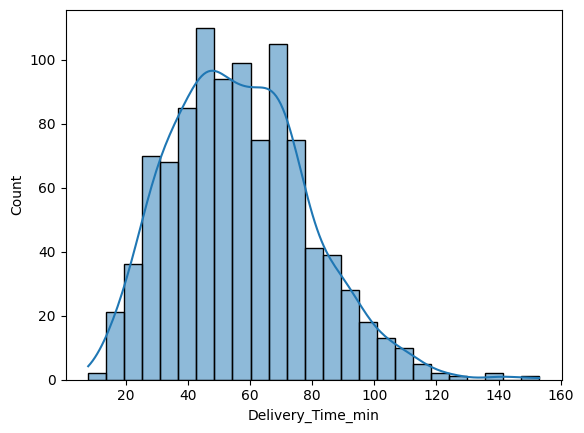

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Delivery_Time_min"],kde=True)
plt.show()

<Axes: xlabel='Delivery_Time_min'>

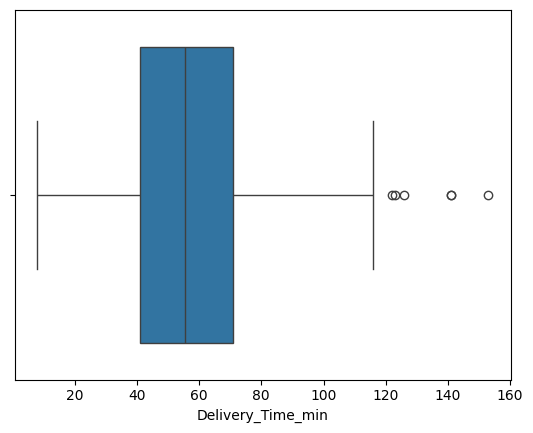

In [0]:
sns.boxplot(x=df["Delivery_Time_min"])

In [0]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [0]:
df.duplicated().sum()

np.int64(0)

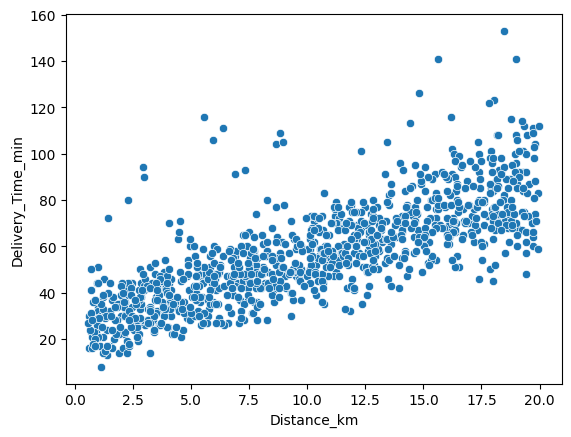

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="Distance_km",
    y="Delivery_Time_min",
    
    data=df
)
plt.show()

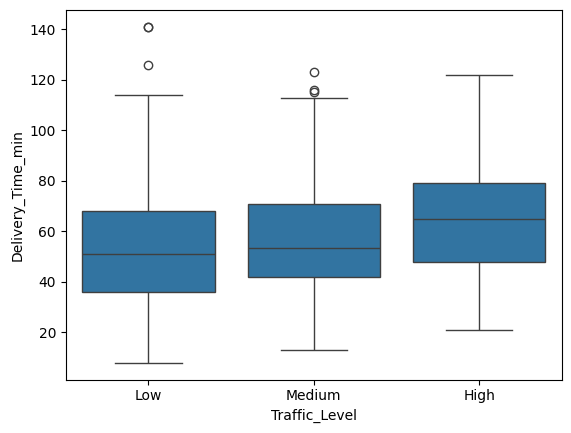

In [0]:
sns.boxplot(
    x="Traffic_Level",
    y="Delivery_Time_min",
    
    data=df
)

plt.show()


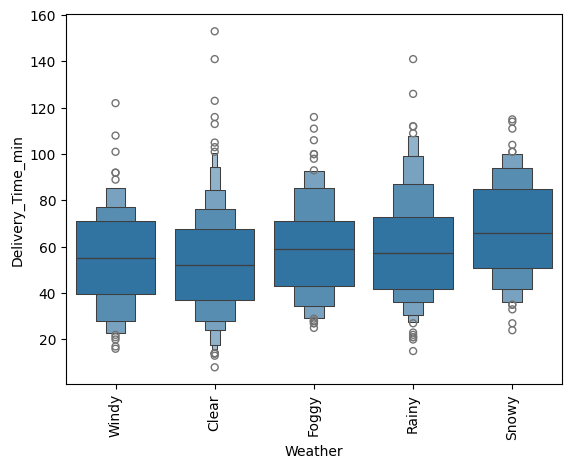

In [0]:
sns.boxenplot(
    x="Weather",
    y="Delivery_Time_min",
    data=df
)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Vehicle_Type', ylabel='Delivery_Time_min'>

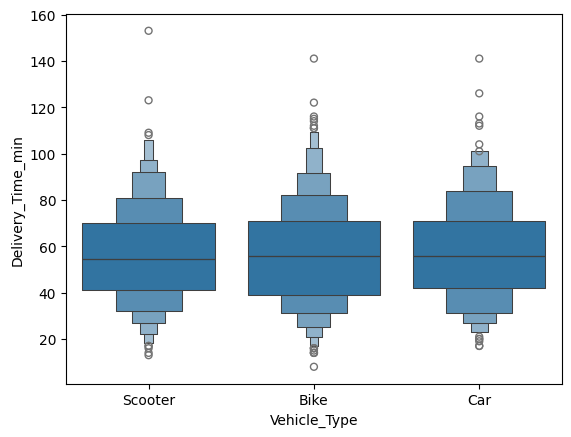

In [0]:
sns.boxenplot(
    x="Vehicle_Type",
    y="Delivery_Time_min",
    data=df
)

<Axes: xlabel='Courier_Experience_yrs', ylabel='Delivery_Time_min'>

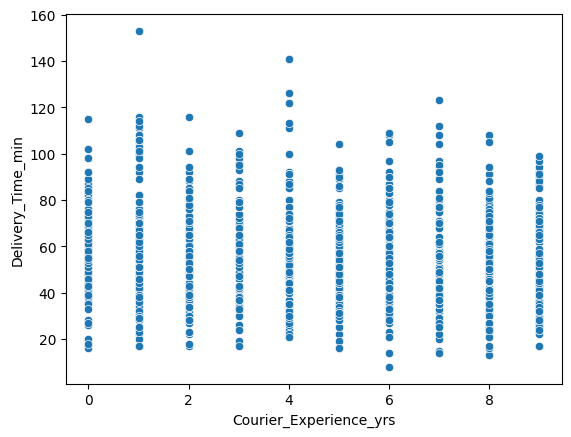

In [0]:
sns.scatterplot(
    x="Courier_Experience_yrs",
    y="Delivery_Time_min",
    data=df )

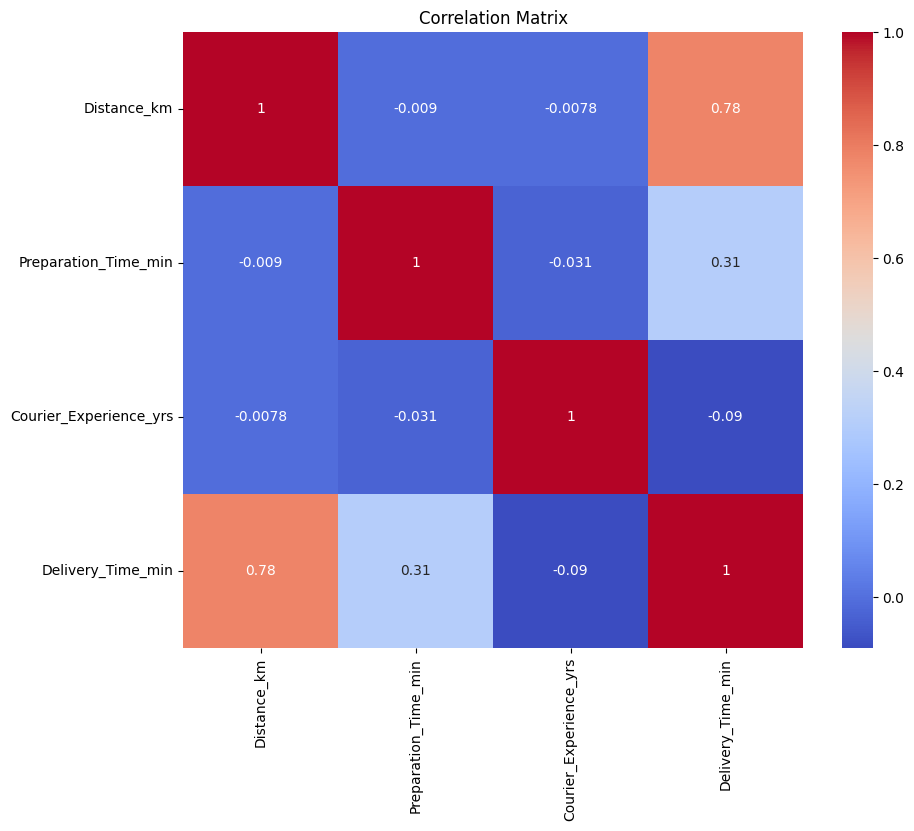

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [0]:
# Outlier Detection using IQR

Q1 = df["Delivery_Time_min"].quantile(0.25)
Q3 = df["Delivery_Time_min"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Delivery_Time_min"] < lower_bound) |
    (df["Delivery_Time_min"] > upper_bound)
]

print("Number of Outliers:", len(outliers))
print(outliers.head())

Number of Outliers: 6
     Distance_km Weather  ... Courier_Experience_yrs Delivery_Time_min
29         18.05   Clear  ...                    7.0               123
127        18.97   Clear  ...                    4.0               141
379        18.46   Clear  ...                    1.0               153
452        15.64   Rainy  ...                    4.0               141
784        14.83   Rainy  ...                    4.0               126

[5 rows x 8 columns]


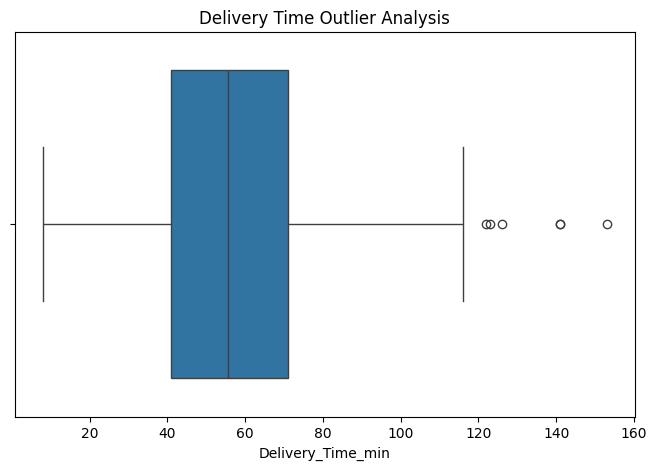

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Delivery_Time_min"])

plt.title("Delivery Time Outlier Analysis")
plt.show()

In [0]:
df["Courier_Experience_yrs"].fillna(
    df["Courier_Experience_yrs"].median(), inplace=True
)


/home/spark-bb7b7a85-d8f6-4188-abd8-14/.ipykernel/333/command-5298522019626817-2396179839:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Courier_Experience_yrs"].fillna(


In [0]:
df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)
df["Vehicle_Type"].fillna(df["Vehicle_Type"].mode()[0], inplace=True)
df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0], inplace=True)
df["Time_of_Day"].fillna(df["Time_of_Day"].mode()[0], inplace=True)

/home/spark-bb7b7a85-d8f6-4188-abd8-14/.ipykernel/333/command-5298522019626819-3382515237:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)
/home/spark-bb7b7a85-d8f6-4188-abd8-14/.ipykernel/333/command-5298522019626819-3382515237:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

In [0]:
df.isnull().sum()


Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [0]:
df.Distance_km

0       7.93
1      16.42
2       9.52
3       7.44
4      19.03
       ...  
995     8.50
996    16.28
997    15.62
998    14.17
999     6.63
Name: Distance_km, Length: 1000, dtype: float64

In [0]:
df.Distance_km

0       7.93
1      16.42
2       9.52
3       7.44
4      19.03
       ...  
995     8.50
996    16.28
997    15.62
998    14.17
999     6.63
Name: Distance_km, Length: 1000, dtype: float64

In [0]:
df["Experince_Level"]=pd.cut(
    df["Courier_Experience_yrs"],
    bins=[0,2,5,10],
    labels=["Beginner","Intermediate","Expert"]
)

In [0]:
df=pd.get_dummies(
    df,
    drop_first=True
)

In [0]:
df.Weather_Foggy

0      False
1      False
2       True
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999     True
Name: Weather_Foggy, Length: 1000, dtype: bool

In [0]:
from sklearn.model_selection import train_test_split

x=df.drop("Delivery_Time_min",axis=1)
y=df["Delivery_Time_min"]

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

## First Model

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features and Target
x = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
rf = RandomForestRegressor(random_state=42)

rf.fit(x_train, y_train)

# Predictions
y_pred = rf.predict(x_test)

print(y_pred[:10])

[33.96 69.07 38.56 49.65 82.54 30.96 66.88 34.4  28.87 76.69]


In [0]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae= mean_absolute_error(y_test,y_pred)

rmse=mean_squared_error(y_test,y_pred)**0.5

r2=r2_score(y_test,y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print("r2 score : ",r2)


MAE: 7.1721
RMSE: 10.351426423445226
r2 score :  0.7609424800905835


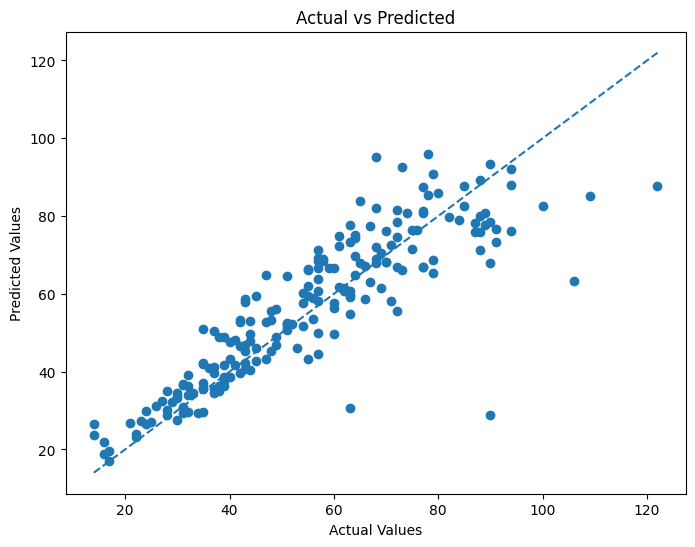

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

## Model 2 Decision Tree

In [0]:
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor( random_state=42)

dt.fit(x_train,y_train)

y_pred=dt.predict(x_test)

mae= mean_absolute_error(y_test,y_pred)

rmse=mean_squared_error(y_test,y_pred)**0.5

r2=r2_score(y_test,y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print("r2 score : ",r2)

MAE: 11.105
RMSE: 15.640811999381617
r2 score :  0.45421624836390095


## Random Forest

In [0]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train,y_train)

y_pred_rf = rf.predict(x_test)

This tells you which factors affect delivery time the most.


In [0]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                         Feature  Importance
0                    Distance_km    0.697705
1           Preparation_Time_min    0.156083
2         Courier_Experience_yrs    0.037279
7              Traffic_Level_Low    0.019471
5                  Weather_Snowy    0.011487
9            Time_of_Day_Evening    0.011058
4                  Weather_Rainy    0.010713
3                  Weather_Foggy    0.008552
12              Vehicle_Type_Car    0.008459
14  Experince_Level_Intermediate    0.007612
13          Vehicle_Type_Scooter    0.007549
8           Traffic_Level_Medium    0.006739
10           Time_of_Day_Morning    0.006189
11             Time_of_Day_Night    0.004080
15        Experince_Level_Expert    0.004019
6                  Weather_Windy    0.003004


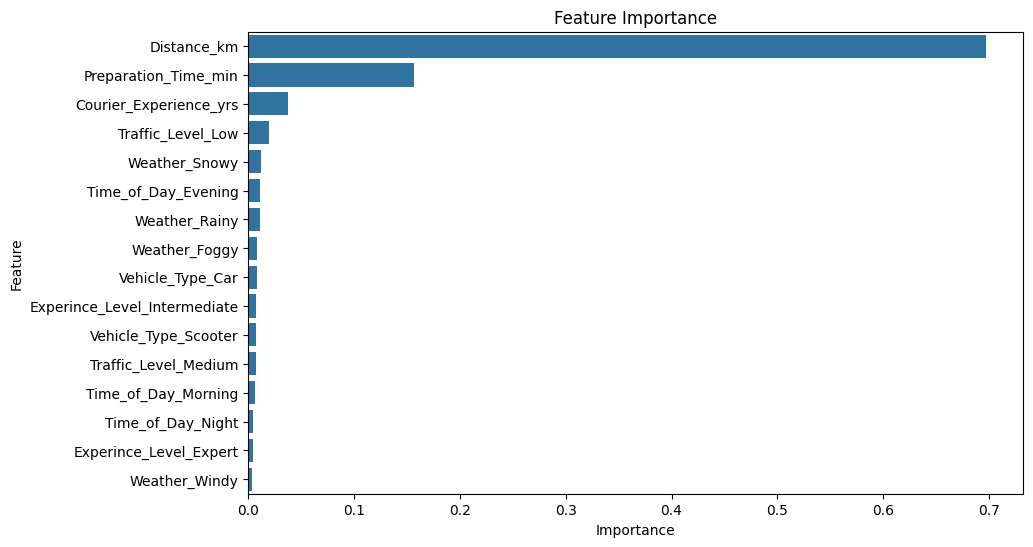

In [0]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

Hyperparameter tuning was performed using GridSearchCV to identify the optimal model configuration.

In [0]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 200}
Best Score:
0.6925275875108596


## Extra Trees

In [0]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et.fit(x_train,y_train)

y_pred_et = et.predict(x_test)

## Gradient Boosting

In [0]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(x_train,y_train)

y_pred_gb = gb.predict(x_test)

In [0]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ]

   
})


In [0]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

results = []

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb
}

for name, model in models.items():

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        round(mae, 2),
        round(rmse, 2),
        round(r2, 4)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

comparison_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.86,8.78,0.8281
4,Gradient Boosting,6.46,9.54,0.7972
3,Extra Trees,7.04,10.11,0.7718
2,Random Forest,7.17,10.35,0.7609
1,Decision Tree,11.11,15.64,0.4542


In [0]:
best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax()
]

print("Best Model")
print(best_model)

Best Model
Model       Linear Regression
MAE                      5.86
RMSE                     8.78
R2 Score               0.8281
Name: 0, dtype: object


In [0]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print("Average R2:", scores.mean())

[0.70361794 0.80794556 0.78804174 0.75470891 0.78743325]
Average R2: 0.768349478246241


In [0]:
df.corr(numeric_only=True)

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter,Experince_Level_Intermediate,Experince_Level_Expert
Distance_km,1.000000,-0.009037,-0.007534,0.780998,-0.026329,0.029239,0.072625,-0.001513,0.013491,-0.040437,-0.015852,0.034545,-0.029308,0.023984,-0.007188,-0.011469,0.018023
Preparation_Time_min,-0.009037,1.000000,-0.030842,0.307350,-0.016514,0.016773,0.019119,-0.047268,0.026823,-0.012785,0.038528,-0.026104,0.007235,0.000529,0.019490,0.030875,-0.033793
Courier_Experience_yrs,-0.007534,-0.030842,1.000000,-0.089111,-0.053854,0.071109,0.012452,0.032136,-0.023466,-0.016690,0.017260,-0.043534,-0.007897,-0.006544,0.000923,-0.102527,0.845459
Delivery_Time_min,0.780998,0.307350,-0.089111,1.000000,0.041997,0.070271,0.154239,-0.018815,-0.137392,-0.010786,0.021864,0.009064,-0.021004,0.032752,-0.020444,0.025949,-0.068911
Weather_Foggy,-0.026329,-0.016514,-0.053854,0.041997,1.000000,-0.171546,-0.111062,-0.110427,0.051103,-0.055059,-0.015751,-0.012616,0.050078,-0.000706,-0.000760,-0.002036,-0.040999
Weather_Rainy,0.029239,0.016773,0.071109,0.070271,-0.171546,1.000000,-0.165921,-0.164972,0.009536,-0.028559,0.028505,-0.031225,-0.011924,0.026432,0.002119,-0.119702,0.118938
Weather_Snowy,0.072625,0.019119,0.012452,0.154239,-0.111062,-0.165921,1.000000,-0.106805,0.047605,-0.052987,0.026570,-0.012757,-0.002968,0.051894,-0.068398,0.040657,0.002247
Weather_Windy,-0.001513,-0.047268,0.032136,-0.018815,-0.110427,-0.164972,-0.106805,1.000000,-0.075192,0.045943,-0.060621,0.061371,-0.026291,0.010967,-0.044302,0.035585,0.018890
Traffic_Level_Low,0.013491,0.026823,-0.023466,-0.137392,0.051103,0.009536,0.047605,-0.075192,1.000000,-0.670452,-0.014549,-0.006323,-0.040975,0.063941,-0.061231,-0.016264,-0.002707
Traffic_Level_Medium,-0.040437,-0.012785,-0.016690,-0.010786,-0.055059,-0.028559,-0.052987,0.045943,-0.670452,1.000000,0.026443,0.008738,0.031240,-0.050627,0.053662,0.006760,-0.036183


In [0]:
df.corr(numeric_only=True)

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter,Experince_Level_Intermediate,Experince_Level_Expert
Distance_km,1.000000,-0.009037,-0.007534,0.780998,-0.026329,0.029239,0.072625,-0.001513,0.013491,-0.040437,-0.015852,0.034545,-0.029308,0.023984,-0.007188,-0.011469,0.018023
Preparation_Time_min,-0.009037,1.000000,-0.030842,0.307350,-0.016514,0.016773,0.019119,-0.047268,0.026823,-0.012785,0.038528,-0.026104,0.007235,0.000529,0.019490,0.030875,-0.033793
Courier_Experience_yrs,-0.007534,-0.030842,1.000000,-0.089111,-0.053854,0.071109,0.012452,0.032136,-0.023466,-0.016690,0.017260,-0.043534,-0.007897,-0.006544,0.000923,-0.102527,0.845459
Delivery_Time_min,0.780998,0.307350,-0.089111,1.000000,0.041997,0.070271,0.154239,-0.018815,-0.137392,-0.010786,0.021864,0.009064,-0.021004,0.032752,-0.020444,0.025949,-0.068911
Weather_Foggy,-0.026329,-0.016514,-0.053854,0.041997,1.000000,-0.171546,-0.111062,-0.110427,0.051103,-0.055059,-0.015751,-0.012616,0.050078,-0.000706,-0.000760,-0.002036,-0.040999
Weather_Rainy,0.029239,0.016773,0.071109,0.070271,-0.171546,1.000000,-0.165921,-0.164972,0.009536,-0.028559,0.028505,-0.031225,-0.011924,0.026432,0.002119,-0.119702,0.118938
Weather_Snowy,0.072625,0.019119,0.012452,0.154239,-0.111062,-0.165921,1.000000,-0.106805,0.047605,-0.052987,0.026570,-0.012757,-0.002968,0.051894,-0.068398,0.040657,0.002247
Weather_Windy,-0.001513,-0.047268,0.032136,-0.018815,-0.110427,-0.164972,-0.106805,1.000000,-0.075192,0.045943,-0.060621,0.061371,-0.026291,0.010967,-0.044302,0.035585,0.018890
Traffic_Level_Low,0.013491,0.026823,-0.023466,-0.137392,0.051103,0.009536,0.047605,-0.075192,1.000000,-0.670452,-0.014549,-0.006323,-0.040975,0.063941,-0.061231,-0.016264,-0.002707
Traffic_Level_Medium,-0.040437,-0.012785,-0.016690,-0.010786,-0.055059,-0.028559,-0.052987,0.045943,-0.670452,1.000000,0.026443,0.008738,0.031240,-0.050627,0.053662,0.006760,-0.036183


In [0]:

y_pred_rf
y_pred_et
y_pred_gb

array([ 35.49884639,  66.64774802,  42.43028245,  45.64991336,
        80.59651816,  33.41899377,  70.3017988 ,  33.22509256,
        36.64380347,  76.29966785,  75.14347363,  63.4270857 ,
        32.92682156,  73.62337124,  96.32386079,  84.70888049,
        33.68898367,  67.24986839,  45.04463805,  63.49505253,
        82.9024005 ,  30.16973357,  83.64186361,  79.69725906,
        59.2694896 ,  34.09204178,  79.52445062,  24.25248558,
        46.91062597,  66.16180467,  67.99013581,  18.58367892,
        56.61380253,  38.40925266,  64.88408752,  20.2866734 ,
        63.75155386,  56.3494602 ,  49.01726507,  76.56098693,
        73.31817952,  31.26545979,  76.79799772,  66.66222856,
        46.55127406,  16.88225298,  85.24631612,  82.6076124 ,
       100.43922768,  28.5920389 ,  65.0167602 ,  62.72382275,
        39.36149176,  80.98205816,  54.67657898,  56.04609428,
        73.87119085,  77.34669124,  63.10542598,  95.34031459,
        52.91923244,  33.44582075,  47.5484269 ,  47.70

In [0]:
y_pred = rf.predict(x_test)

residuals = y_test - y_pred

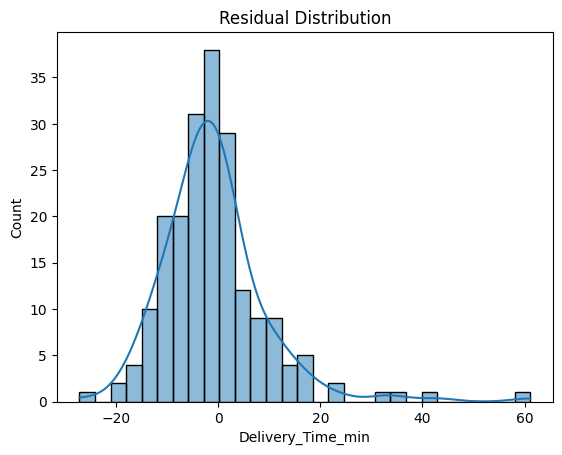

In [0]:
sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

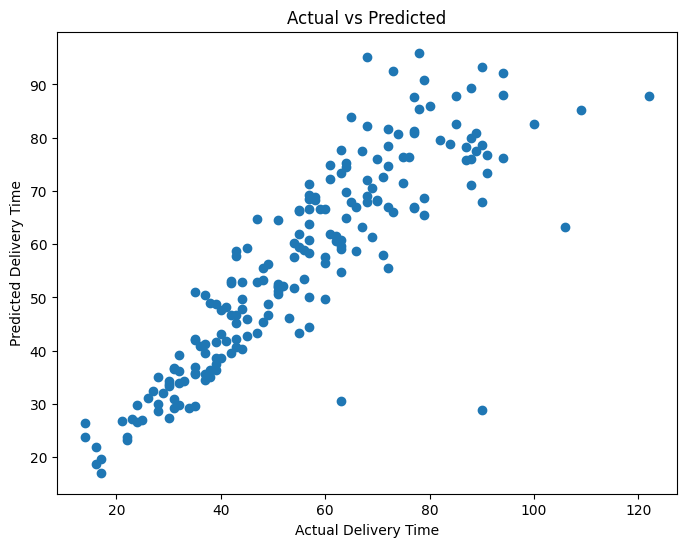

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted")

plt.show()

In [0]:
best_model = rf

In [0]:
comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.86,8.78,0.8281
4,Gradient Boosting,6.46,9.54,0.7972
3,Extra Trees,7.04,10.11,0.7718
2,Random Forest,7.17,10.35,0.7609
1,Decision Tree,11.11,15.64,0.4542


Multiple regression models were trained and evaluated using MAE, RMSE, and R² Score. Linear Regression achieved the highest R² score (0.8281) and the lowest MAE (5.86) and RMSE (8.78). Therefore, Linear Regression was selected as the final model.

Although ensemble models such as Random Forest and Extra Trees are powerful, the evaluation metrics showed that Linear Regression achieved the highest R² score and the lowest prediction error. This indicates that the relationship between the selected features and delivery time is largely linear, making Linear Regression the most suitable model for this dataset.

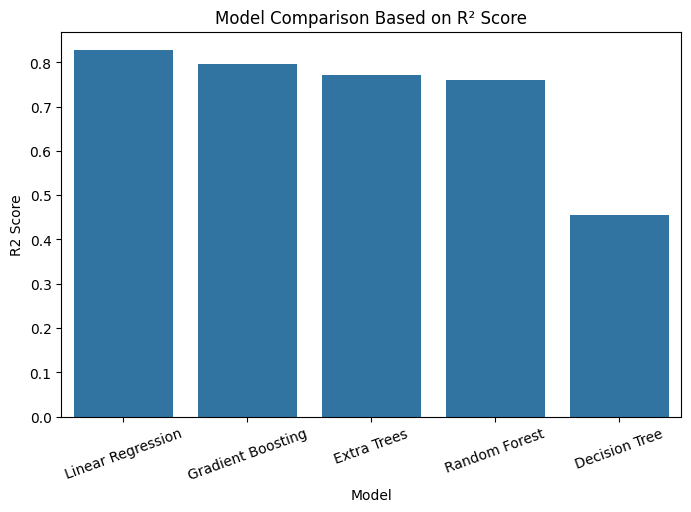

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xticks(rotation=20)

plt.show()

Linear Regression was identified as the best-performing model with an R² Score of 0.8281, MAE of 5.86, and RMSE of 8.78. The model can effectively predict food delivery time and can be used to improve ETA estimation, customer satisfaction, and delivery planning.

In [0]:
# Predict first test record

sample = x_test.iloc[[0]]

prediction = lr.predict(sample)

print("Predicted Delivery Time:", prediction[0])
print("Actual Delivery Time:", y_test.iloc[0])

Predicted Delivery Time: 35.826285915820705
Actual Delivery Time: 32


In [0]:
sample = x_test.iloc[[0]].copy()

prediction = lr.predict(sample)

print("Predicted Delivery Time:", round(prediction[0],2))

Predicted Delivery Time: 35.83
